# Step 7 — Build M0 candidate pairs (feature engineering + scoring)

Interactive version of `scripts/build_m0_candidate_pairs.py` — **running this notebook regenerates
`data/processed/boamp_m0_candidate_pairs.csv`**.

Candidate generation (deterministic, no external enrichment): same `buyer_key`, a later APPEL_OFFRE
notice, published within a temporal window around the source's `estimated_end_date`. Each pair gets
four similarity features (`s_text` TF-IDF cosine, `s_cpv` hierarchy score, `s_time` proximity to
expected end, `s_buyer` key reliability) combined into `m0_composite_score`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from IPython.display import display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)

## Scoring rules (tweak and re-run)

- CPV hierarchy rungs: exact > category > class > group > division > different, with "missing"
  treated as weak-neutral evidence (0.1) - absence of information, not proof of mismatch.
- `s_buyer` reflects how trustworthy the buyer-key match is (generation already conditions on
  buyer_key equality).
- Composite weights: text and CPV are the primary content signals; time anchors the match around
  the expected contract end; buyer discounts name-only matches.

In [2]:
MAX_WINDOW_MONTHS_CAP = 24
MIN_WINDOW_MONTHS_FLOOR = 6

CPV_SCORE_EXACT = 1.0
CPV_SCORE_CATEGORY = 0.8
CPV_SCORE_CLASS = 0.6
CPV_SCORE_GROUP = 0.4
CPV_SCORE_DIVISION = 0.2
CPV_SCORE_DIFFERENT = 0.0
CPV_SCORE_MISSING = 0.1

BUYER_KEY_TYPE_SCORE = {
    "RAW_SIRET": 1.0,
    "RAW_SIREN": 0.85,
    "NAME_FALLBACK": 0.6,
}

W_TEXT, W_CPV, W_TIME, W_BUYER = 0.35, 0.30, 0.25, 0.10

# Practical cap on candidates scored per source (bounds runtime for large,
# high-frequency buyers; only the temporally-nearest are kept).
MAX_CANDIDATES_PER_SOURCE = 30


def cpv_pair_score(src_main, cand_main, src_cat, cand_cat, src_cls, cand_cls,
                    src_grp, cand_grp, src_div, cand_div):
    if pd.isna(src_main) or pd.isna(cand_main):
        return CPV_SCORE_MISSING
    if src_main == cand_main:
        return CPV_SCORE_EXACT
    if src_cat == cand_cat:
        return CPV_SCORE_CATEGORY
    if src_cls == cand_cls:
        return CPV_SCORE_CLASS
    if src_grp == cand_grp:
        return CPV_SCORE_GROUP
    if src_div == cand_div:
        return CPV_SCORE_DIVISION
    return CPV_SCORE_DIFFERENT

## Load the M0 source population

In [3]:
str_cols = ["notice_id", "buyer_key", "buyer_key_type", "buyer_name_normalized",
            "buyer_siret_clean", "buyer_siren_clean", "objet_clean",
            "cpv_clean", "cpv_division", "cpv_category", "cpv_class", "cpv_group",
            "category_label"]
src = pd.read_csv(PROCESSED_DIR / "boamp_m0_sources.csv",
                   dtype={c: str for c in str_cols},
                   parse_dates=["publication_date", "start_date", "estimated_end_date", "study_end_date"])
print(f"Loaded {len(src)} APPEL_OFFRE source rows")

eligible = src[src["buyer_key_type"] != "MISSING"].copy()
eligible = eligible.sort_values(["buyer_key", "publication_date"]).reset_index(drop=True)
print(f"Eligible (non-missing buyer_key) sources: {len(eligible)}")

Loaded 3159 APPEL_OFFRE source rows
Eligible (non-missing buyer_key) sources: 3159


## Derive the temporal window from the observed duration distribution

The candidate window is `clip(0.5 * median observed duration, 6, 24)` months around the estimated
end date - derived from the data, not a fixed guess.

In [4]:
dur = eligible.loc[~eligible["dur_was_imputed"], "declared_duration_months"].dropna()
median_dur = dur.median() if len(dur) else eligible["declared_duration_months"].median()
window = int(np.clip(round(median_dur * 0.5), MIN_WINDOW_MONTHS_FLOOR, MAX_WINDOW_MONTHS_CAP))
print(f"Observed (non-imputed) duration median: {median_dur:.1f} months")
print(f"TEMPORAL_WINDOW_MONTHS = clip(0.5 * median_duration, {MIN_WINDOW_MONTHS_FLOOR}, {MAX_WINDOW_MONTHS_CAP}) = {window}")

Observed (non-imputed) duration median: 6.0 months
TEMPORAL_WINDOW_MONTHS = clip(0.5 * median_duration, 6, 24) = 6


## TF-IDF over all eligible source texts (also the candidate pool)

In [5]:
texts = eligible["objet_clean"].fillna("").tolist()
vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2)
tfidf = vectorizer.fit_transform(texts)
print(f"TF-IDF matrix: {tfidf.shape}")

TF-IDF matrix: (3159, 7299)


## Generate and score candidate pairs (per buyer group, binary search on the window)

In [6]:
notice_ids = eligible["notice_id"].to_numpy()
pub_dates_all = eligible["publication_date"].to_numpy()
end_dates_all = eligible["estimated_end_date"].to_numpy()
cpv_main_all = eligible["cpv_clean"].to_numpy(dtype=object)
cpv_cat_all = eligible["cpv_category"].to_numpy(dtype=object)
cpv_cls_all = eligible["cpv_class"].to_numpy(dtype=object)
cpv_grp_all = eligible["cpv_group"].to_numpy(dtype=object)
cpv_div_all = eligible["cpv_division"].to_numpy(dtype=object)
cpv_generic_all = eligible["cpv_generic_flag"].to_numpy()
buyer_key_type_all = eligible["buyer_key_type"].to_numpy(dtype=object)

window_td = np.timedelta64(int(round(window * 30.44)), "D")

records = []
group_indices = eligible.groupby("buyer_key", sort=False).indices
n_groups = len(group_indices)
print(f"Processing {n_groups} buyer groups...")

for gi, (buyer_key, idx) in enumerate(group_indices.items()):
    n = len(idx)
    if n < 2:
        continue
    idx = np.asarray(idx)
    g_pub = pub_dates_all[idx]
    g_end = end_dates_all[idx]

    for i in range(n):
        expected_end = g_end[i]
        if pd.isna(expected_end):
            continue
        src_date = g_pub[i]
        lo = expected_end - window_td
        hi = expected_end + window_td
        left = np.searchsorted(g_pub, lo, side="left")
        right = np.searchsorted(g_pub, hi, side="right")
        if right <= left:
            continue
        cand_local = np.arange(left, right)
        cand_local = cand_local[(g_pub[cand_local] > src_date) & (cand_local != i)]
        if len(cand_local) == 0:
            continue

        cand_global = idx[cand_local]
        i_global = idx[i]

        abs_gap_arr = np.abs((g_pub[cand_local] - expected_end)) / np.timedelta64(1, "D") / 30.44
        if len(cand_local) > MAX_CANDIDATES_PER_SOURCE:
            keep = np.argsort(abs_gap_arr)[:MAX_CANDIDATES_PER_SOURCE]
            cand_local = cand_local[keep]
            cand_global = cand_global[keep]
            abs_gap_arr = abs_gap_arr[keep]

        gap_months_arr = (g_pub[cand_local] - src_date) / np.timedelta64(1, "D") / 30.44
        s_time_arr = np.clip(1.0 - abs_gap_arr / window, 0.0, None)

        sims = tfidf[cand_global].dot(tfidf[i_global].T).toarray().ravel()

        src_cpv_main, src_cpv_cat = cpv_main_all[i_global], cpv_cat_all[i_global]
        src_cpv_cls, src_cpv_grp, src_cpv_div = cpv_cls_all[i_global], cpv_grp_all[i_global], cpv_div_all[i_global]
        src_generic = bool(cpv_generic_all[i_global])
        bkt = buyer_key_type_all[i_global]
        s_buyer = BUYER_KEY_TYPE_SCORE.get(bkt, 0.0)

        for k, cg in enumerate(cand_global):
            s_cpv = cpv_pair_score(
                src_cpv_main, cpv_main_all[cg],
                src_cpv_cat, cpv_cat_all[cg],
                src_cpv_cls, cpv_cls_all[cg],
                src_cpv_grp, cpv_grp_all[cg],
                src_cpv_div, cpv_div_all[cg],
            )
            s_text = float(sims[k])
            composite = W_TEXT * s_text + W_CPV * s_cpv + W_TIME * s_time_arr[k] + W_BUYER * s_buyer
            records.append({
                "source_notice_id": notice_ids[i_global],
                "candidate_notice_id": notice_ids[cg],
                "source_date": src_date,
                "candidate_date": g_pub[cand_local[k]],
                "buyer_key": buyer_key,
                "buyer_key_type": bkt,
                "gap_months": gap_months_arr[k],
                "expected_end_date": expected_end,
                "abs_gap_to_expected_end": abs_gap_arr[k],
                "s_time": s_time_arr[k],
                "s_text": s_text,
                "s_cpv": s_cpv,
                "s_buyer": s_buyer,
                "m0_composite_score": composite,
                "cpv_missing": bool(pd.isna(src_cpv_main) or pd.isna(cpv_main_all[cg])),
                "cpv_generic_flag": bool(src_generic or cpv_generic_all[cg]),
            })

    if gi % 2000 == 0:
        print(f"  ...{gi}/{n_groups} buyer groups processed, {len(records)} pairs so far", flush=True)

pairs = pd.DataFrame.from_records(records)
print(f"\nGenerated {len(pairs)} raw candidate pairs")

Processing 790 buyer groups...

Generated 6137 raw candidate pairs


## Rank candidates per source and compute the top1-top2 margin

In [7]:
if len(pairs):
    pairs = pairs.sort_values(["source_notice_id", "m0_composite_score"], ascending=[True, False])
    pairs["candidate_rank"] = pairs.groupby("source_notice_id").cumcount() + 1
    pairs["n_candidates_for_source"] = pairs.groupby("source_notice_id")["candidate_notice_id"].transform("count")

    top2 = (
        pairs[pairs["candidate_rank"] <= 2]
        .pivot(index="source_notice_id", columns="candidate_rank", values="m0_composite_score")
    )
    margin = (top2.get(1) - top2.get(2)).fillna(top2.get(1))
    pairs["top1_top2_margin"] = pairs["source_notice_id"].map(margin)

out_path = PROCESSED_DIR / "boamp_m0_candidate_pairs.csv"
pairs.to_csv(out_path, index=False)
print(f"Wrote candidate pairs -> {out_path}")

# Persist the derived window for downstream steps/report to reuse.
with open(PROCESSED_DIR / "_m0_window_months.txt", "w") as f:
    f.write(str(window))

n_sources_with_candidates = pairs["source_notice_id"].nunique() if len(pairs) else 0
print(f"TEMPORAL_WINDOW_MONTHS used: {window}")
print(f"Eligible sources: {len(eligible)}")
print(f"Sources with >=1 candidate: {n_sources_with_candidates}")
print(f"Total candidate pairs: {len(pairs)}")
display(pairs[["m0_composite_score", "s_text", "s_cpv", "s_time", "s_buyer"]].describe())

Wrote candidate pairs -> /home/senghakrou/survival-analysis/data/processed/boamp_m0_candidate_pairs.csv
TEMPORAL_WINDOW_MONTHS used: 6
Eligible sources: 3159
Sources with >=1 candidate: 1236
Total candidate pairs: 6137


,m0_composite_score,s_text,s_cpv,s_time,s_buyer
count,6137.000000,6137.000000,6137.000000,6137.000000,6137.000000
mean,0.250497,0.083416,0.103226,0.498156,0.657944
std,0.110876,0.155049,0.179224,0.291157,0.140795
min,0.060000,0.000000,0.000000,0.000000,0.600000
25%,0.171744,0.011194,0.000000,0.238940,0.600000
50%,0.240778,0.027304,0.100000,0.501752,0.600000
75%,0.308204,0.088577,0.100000,0.753614,0.600000
max,0.938148,1.000000,1.000000,1.000000,1.000000


## Figures (same filenames as `scripts/make_figures.py`, figures 06-07)

In [8]:
import matplotlib.pyplot as plt

# Palette tokens (light mode) - the project's validated dataviz reference palette,
# identical to scripts/make_figures.py so notebook and script output match.
SURFACE = "#fcfcfb"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"

CAT = {
    "blue": "#2a78d6", "aqua": "#1baf7a", "yellow": "#eda100", "green": "#008300",
    "violet": "#4a3aa7", "red": "#e34948", "magenta": "#e87ba4", "orange": "#eb6834",
}

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_PRIMARY,
    "text.color": INK_PRIMARY,
    "xtick.color": INK_SECONDARY,
    "ytick.color": INK_SECONDARY,
    "axes.grid": True,
    "grid.color": GRIDLINE,
    "grid.linewidth": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
    "font.size": 10.5,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "figure.dpi": 120,
})

FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_and_show(fig, name):
    """Save under reports/figures (same filenames as the figure scripts) and display inline."""
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{name}.pdf")
    fig.savefig(FIG_DIR / f"{name}.png", dpi=200)
    plt.show()

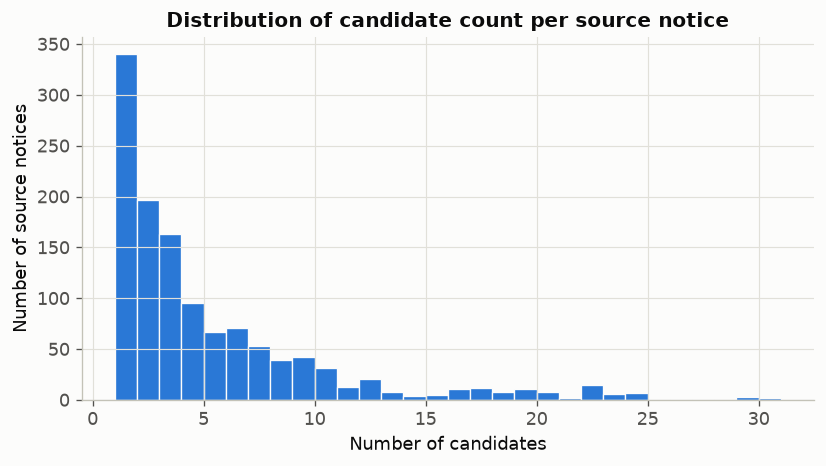

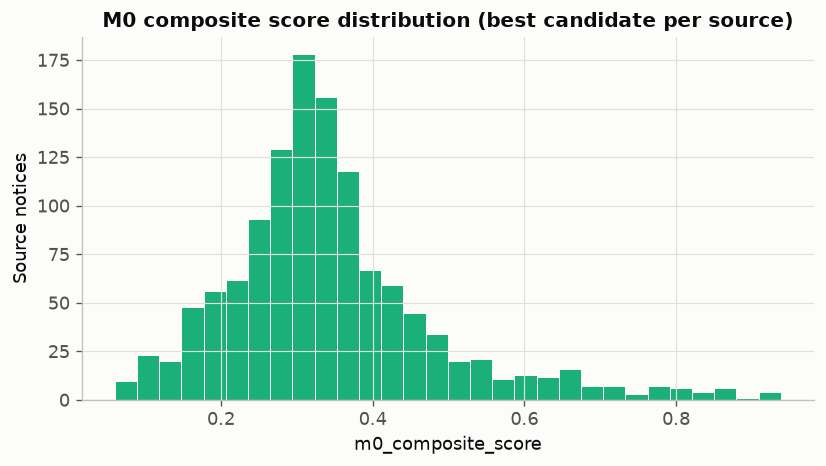

In [9]:
if len(pairs):
    n_cand = pairs.groupby("source_notice_id").size()
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(n_cand.values, bins=range(1, int(n_cand.max()) + 2), color=CAT["blue"],
            edgecolor=SURFACE, linewidth=0.8)
    ax.set_title("Distribution of candidate count per source notice")
    ax.set_xlabel("Number of candidates")
    ax.set_ylabel("Number of source notices")
    save_and_show(fig, "06_candidate_count_distribution")

    rank1 = pairs[pairs["candidate_rank"] == 1]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(rank1["m0_composite_score"], bins=30, color=CAT["aqua"], edgecolor=SURFACE, linewidth=0.6)
    ax.set_title("M0 composite score distribution (best candidate per source)")
    ax.set_xlabel("m0_composite_score")
    ax.set_ylabel("Source notices")
    save_and_show(fig, "07_m0_score_distribution")